# Phase 2: Exploratory Analysis

Explores the `hourly_demand` table to tell the market shift story across Yellow, Green, and HVFHV 2019-2025. All charts use `.toPandas()` to pull aggregated data from Spark into matplotlib/seaborn for plotting.

## Contents
1. Total Monthly Trips Over Time by Vehicle Type (stacked area)
2. Market Share % by Vehicle Type Over Time (line)
3. COVID Crash Zoom-In (March-June 2020) (line)
4. Average Trips by Hour of Day (bar)
5. Average Trips by Day of Week (bar)
6. Average Trips by Month of Year (bar)
7. Average Trips by Hour of Day X Day of Week (heatmap)

## Imports 

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter, WeekdayLocator, MO
import datetime
import seaborn as sns
from pyspark.sql.functions import col, year, month, hour, dayofweek, avg, sum as spark_sum, date_trunc

Note

HOUR(), DAYOFWEEK(), MONTH(), YEAR() -- extract a number (integer category). Use these when you want to group by a repeating pattern: "all 9pm hours across the entire dataset", "all Mondays", "all Januaries". The output is just 0-23, 1-7, 1-12 etc. It has no concept of which specific date it came from.

date_trunc("day", hour), date_trunc("month", hour) -- snap a timestamp back to the start of a period, returning a timestamp value. Use this when you want a specific point in time: "the week of 2020-03-02", "the month of 2019-01-01". The output is still a real date that pandas/matplotlib can put on a time axis.

#### Chart 1: Total Monthly Trips Over Time by Vehicle Type

In [0]:
monthly_trips = spark.sql("""
    SELECT 
        date_trunc("month", hour) AS month,
        vehicle_type,
        SUM(trip_count) AS trip_count
    FROM hourly_demand
    WHERE hour >= '2019-01-01' AND hour < '2026-01-01'
    GROUP BY month, vehicle_type
""").toPandas()


In [0]:
monthly_trips_pivoted = monthly_trips.pivot(columns = "vehicle_type", index = "month", values = "trip_count")

In [0]:
monthly_trips_pivoted

vehicle_type,green,hvfhv,yellow
month,,,
2019-01-01,671992.0,NaN,7696080.0
2019-02-01,615512.0,20159102.0,7048744.0
2019-03-01,642987.0,23864598.0,7866110.0
2019-04-01,567819.0,21734822.0,7475636.0
2019-05-01,545410.0,22329247.0,7598068.0
...,...,...,...
2025-08-01,46283.0,19271461.0,3574074.0
2025-09-01,48860.0,19434641.0,4251008.0
2025-10-01,49395.0,21308701.0,4428686.0


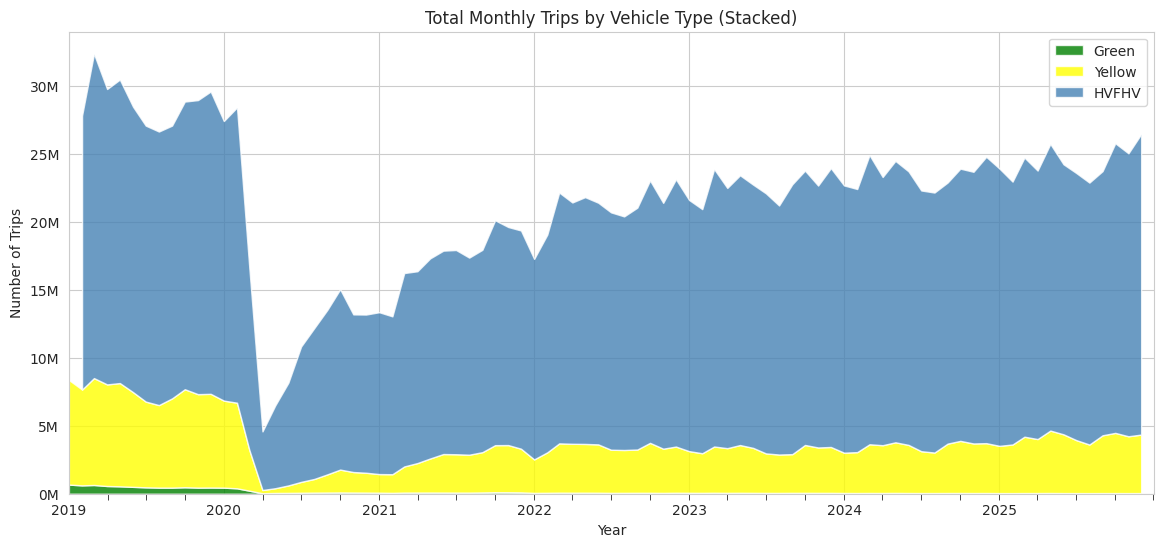

In [0]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))

# Plot
ax.stackplot(   monthly_trips_pivoted.index,
                monthly_trips_pivoted['green'],
                monthly_trips_pivoted['yellow'],
                monthly_trips_pivoted['hvfhv'],
                labels = ['Green', 'Yellow', 'HVFHV'],
                colors = ['green', 'yellow', 'steelblue'],
                alpha = 0.8
)

# Formatting
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.xaxis.set_major_locator(YearLocator())
ax.xaxis.set_major_formatter(DateFormatter('%Y'))
ax.xaxis.set_minor_locator(MonthLocator(bymonth=[1, 4, 7, 10]))
ax.minorticks_on()
ax.tick_params(axis='x', which='minor', bottom=True, length=4)
ax.set_xlim(datetime.date(2019, 1, 1), datetime.date(2025, 12, 31))
ax.margins(x=0)

# Labels
ax.set_ylabel('Number of Trips')
ax.set_xlabel('Year')
ax.set_title('Total Monthly Trips by Vehicle Type (Stacked)')
ax.legend()
plt.show()

The most striking feature is the COVID-19 crash in spring 2020. Total monthly trips fell from 28.4M in February 2020 to 4.6M in April 2020, a drop of 84% in just two months, with demand collapsing across all three vehicle types. Recovery was gradual through 2021-2022 but the market has not returned to pre-COVID levels: the peak was 32.4M trips in March 2019, compared to around 25.5M by end of 2025, a contraction of roughly 22%.

#### Chart 2: Market Share % by Vehicle Type Over Time

In [0]:
# total
monthly_trips_pivoted["total"] = monthly_trips_pivoted['green'] + monthly_trips_pivoted['yellow'] + monthly_trips_pivoted['hvfhv']

# percentages
monthly_trips_pivoted["green_pct"] = monthly_trips_pivoted['green'] / monthly_trips_pivoted["total"] * 100
monthly_trips_pivoted["yellow_pct"] = monthly_trips_pivoted['yellow'] / monthly_trips_pivoted["total"] * 100
monthly_trips_pivoted["hvfhv_pct"] = monthly_trips_pivoted['hvfhv'] / monthly_trips_pivoted["total"] * 100

monthly_trips_pivoted

vehicle_type,green,hvfhv,yellow,total,green_pct,yellow_pct,hvfhv_pct
month,,,,,,,
2019-01-01,671992.0,NaN,7696080.0,NaN,NaN,NaN,NaN
2019-02-01,615512.0,20159102.0,7048744.0,27823358.0,2.212213,25.333908,72.453879
2019-03-01,642987.0,23864598.0,7866110.0,32373695.0,1.986140,24.297844,73.716015
2019-04-01,567819.0,21734822.0,7475636.0,29778277.0,1.906823,25.104327,72.988850
2019-05-01,545410.0,22329247.0,7598068.0,30472725.0,1.789830,24.933996,73.276174
...,...,...,...,...,...,...,...
2025-08-01,46283.0,19271461.0,3574074.0,22891818.0,0.202181,15.612888,84.184930
2025-09-01,48860.0,19434641.0,4251008.0,23734509.0,0.205861,17.910663,81.883476
2025-10-01,49395.0,21308701.0,4428686.0,25786782.0,0.191552,17.174248,82.634200


In [0]:
monthly_trips_pivoted[['green_pct', 'yellow_pct', 'hvfhv_pct']].loc['2020-02-01':'2020-05-01']

vehicle_type,green_pct,yellow_pct,hvfhv_pct
month,,,
2020-02-01,1.402421,22.162033,76.435545
2020-03-01,1.344313,18.090243,80.565445
2020-04-01,0.777022,5.187869,94.035109
2020-05-01,0.883054,5.363382,93.753564


In [0]:
monthly_trips_pivoted[['green_pct', 'yellow_pct', 'hvfhv_pct']].loc['2025-01-01':'2025-12-01']

vehicle_type,green_pct,yellow_pct,hvfhv_pct
month,,,
2025-01-01,0.201775,14.522888,85.275338
2025-02-01,0.202939,15.579073,84.217989
2025-03-01,0.208332,16.759464,83.032204
2025-04-01,0.219207,16.699351,83.081443
2025-05-01,0.215200,17.840349,81.944451
2025-06-01,0.203685,17.833673,81.962641
2025-07-01,0.204202,16.520888,83.274910
2025-08-01,0.202181,15.612888,84.184930
2025-09-01,0.205861,17.910663,81.883476


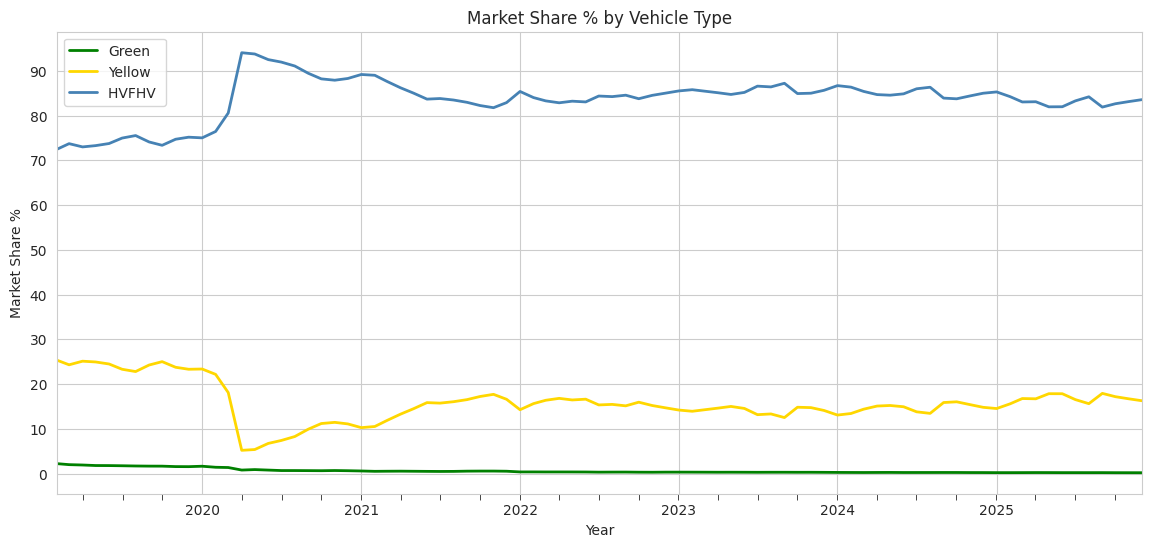

In [0]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))

# Plot 
ax.plot(monthly_trips_pivoted['green_pct'], label='Green', color='green',  linewidth=2)
ax.plot(monthly_trips_pivoted['yellow_pct'], label='Yellow ', color='gold',  linewidth=2)
ax.plot(monthly_trips_pivoted['hvfhv_pct'], label='HVFHV ', color='steelblue',  linewidth=2)
ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
ax.xaxis.set_major_formatter(DateFormatter('%Y'))
ax.xaxis.set_minor_locator(MonthLocator(bymonth=[1, 4, 7, 10]))
ax.minorticks_on()
ax.tick_params(axis='x', which='minor', bottom=True, length=4)
ax.margins(x=0)

# Labels
ax.set_title("Market Share % by Vehicle Type")
ax.set_xlabel("Year")
ax.set_ylabel("Market Share %")
plt.legend()
plt.show()

HVFHV was already the dominant player before COVID, holding 76.4% of trips in February 2020 compared to 22.2% for Yellow and 1.4% for Green. At the peak of the COVID-19 crash in April 2020, HVFHV's share rose to 94.0% while Yellow fell to 5.2% and Green to 0.8%. 

By 2025 the market had settled at a new composition: HVFHV 82-85%, Yellow 15-18%, and Green approximately 0.2%, a near-complete exit from the market. 

Yellow lost roughly 5-7 percentage points of market share permanently, while Green's decline to near zero confirms its structural exit from the NYC for-hire vehicle market. HVFHV gained approximately 6-9 percentage points, consolidating its position as the overwhelmingly dominant force in NYC for-hire vehicle trips.

#### Charts 3 & 3.5: COVID Crash (February–May 2020)

In [0]:
weekly_trips_covid = spark.sql("""
    SELECT 
        date_trunc("week", hour) AS week,
        vehicle_type,
        SUM(trip_count) AS trip_count
    FROM hourly_demand
    WHERE hour >= '2020-02-10' AND hour < '2020-06-01'
    GROUP BY week, vehicle_type
""").toPandas()

In [0]:
weekly_trips_covid_pivoted = weekly_trips_covid.pivot(columns = "vehicle_type", index = "week", values = "trip_count")
weekly_trips_covid_pivoted


vehicle_type,green,hvfhv,yellow
week,,,
2020-02-10,97597,5280428,1540994
2020-02-17,89387,4999837,1420718
2020-02-24,99948,5438868,1572441
2020-03-02,95681,5275219,1508331
2020-03-09,73082,4205708,997752
2020-03-16,29406,1865633,230106
2020-03-23,10977,999965,72279
2020-03-30,9124,909288,59067
2020-04-06,7549,899871,51212


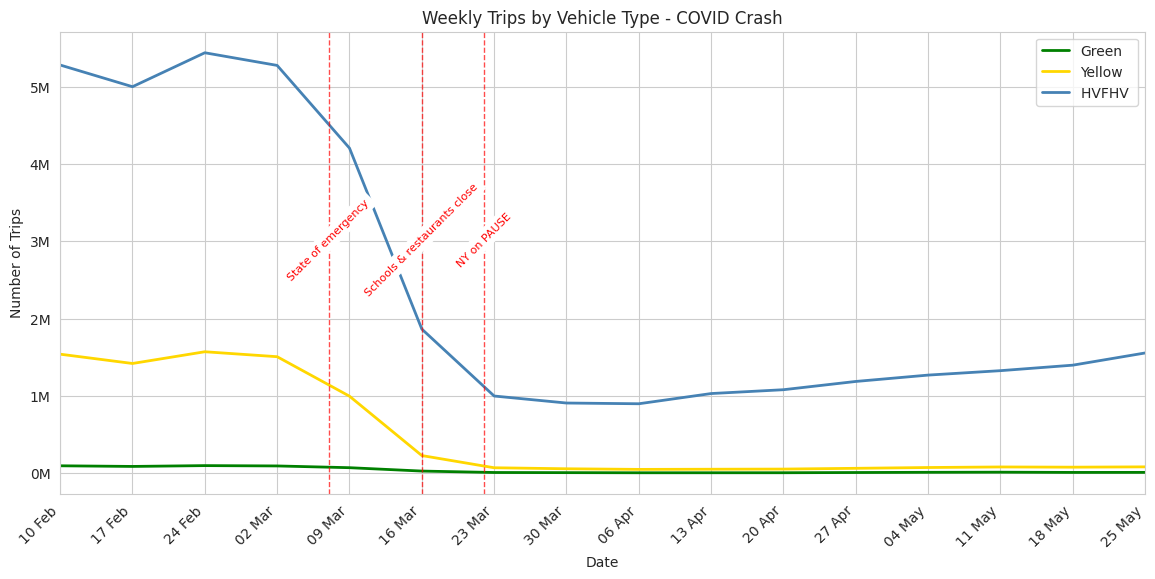

In [0]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))

# Plot 
ax.plot(weekly_trips_covid_pivoted['green'], label='Green', color='green',  linewidth=2)
ax.plot(weekly_trips_covid_pivoted['yellow'], label='Yellow ', color='gold',  linewidth=2)
ax.plot(weekly_trips_covid_pivoted['hvfhv'], label='HVFHV ', color='steelblue',  linewidth=2)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.xaxis.set_major_locator(WeekdayLocator(byweekday=MO))
ax.xaxis.set_major_formatter(DateFormatter('%d %b'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.margins(x=0)


events = {
    '2020-03-07': 'State of emergency',
    '2020-03-16': 'Schools & restaurants close',
    '2020-03-22': 'NY on PAUSE',
}

ymin, ymax = ax.get_ylim()

for date, label in events.items():
    x = pd.Timestamp(date)
    ax.axvline(x, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(x, ymin + (ymax - ymin) * 0.55, label,
            color='red', fontsize=8,
            ha='center', va='center',
            rotation=45,
            bbox=dict(facecolor='white', edgecolor='none', pad=3))

# Labels
ax.set_title("Weekly Trips by Vehicle Type - COVID Crash")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Trips")
plt.legend()
plt.show()

In [0]:
daily_trips_covid = spark.sql("""
    SELECT 
        date_trunc("day", hour) AS day,
        vehicle_type,
        SUM(trip_count) AS trip_count
    FROM hourly_demand
    WHERE hour >= '2020-02-10' AND hour < '2020-06-01'
    GROUP BY day, vehicle_type
""").toPandas()


daily_trips_covid_pivoted = daily_trips_covid.pivot(columns = "vehicle_type", index = "day", values = "trip_count")

daily_trips_covid_pivoted

vehicle_type,green,hvfhv,yellow
day,,,
2020-02-10,13555,681239,211573
2020-02-11,13534,657159,220135
2020-02-12,14963,677386,236425
2020-02-13,15516,746542,246516
2020-02-14,16574,886605,258277
...,...,...,...
2020-05-27,2140,216588,14262
2020-05-28,2045,214980,13584
2020-05-29,2184,246556,15173


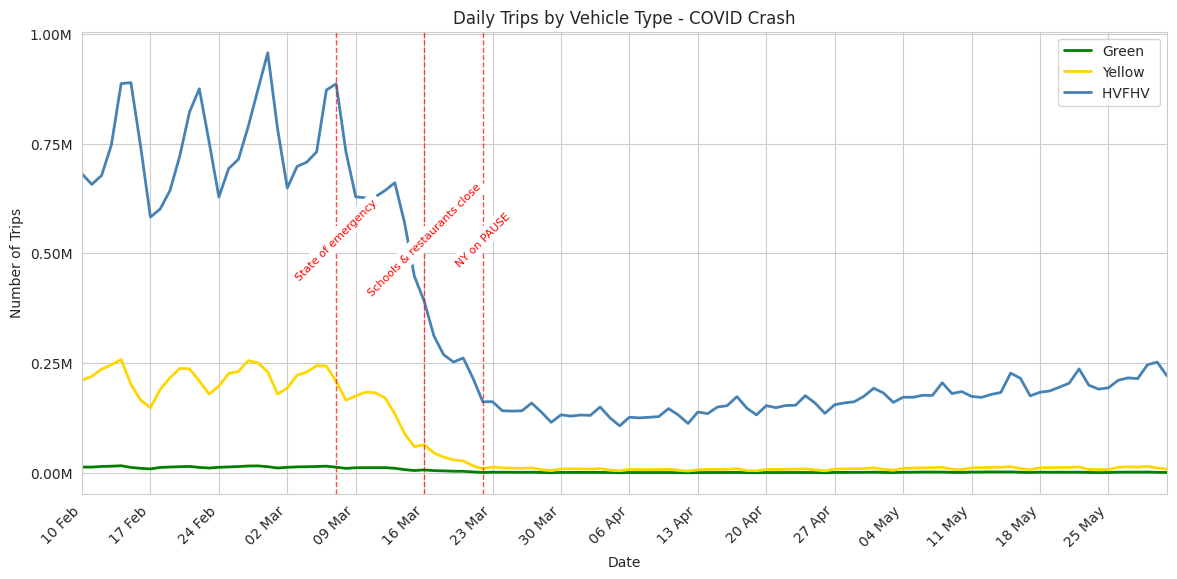

In [0]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))

# Plot 
ax.plot(daily_trips_covid_pivoted['green'], label='Green', color='green',  linewidth=2)
ax.plot(daily_trips_covid_pivoted['yellow'], label='Yellow ', color='gold',  linewidth=2)
ax.plot(daily_trips_covid_pivoted['hvfhv'], label='HVFHV ', color='steelblue',  linewidth=2)
ax.yaxis.set_major_locator(ticker.MultipleLocator(250_000))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
ax.xaxis.set_major_locator(WeekdayLocator(byweekday=MO))
ax.xaxis.set_major_formatter(DateFormatter('%d %b'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.margins(x=0)


events = {
    '2020-03-07': 'State of emergency',
    '2020-03-16': 'Schools & restaurants close',
    '2020-03-22': 'NY on PAUSE',
}

ymin, ymax = ax.get_ylim()

for date, label in events.items():
    x = pd.Timestamp(date)
    ax.axvline(x, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(x, ymin + (ymax - ymin) * 0.55, label,
            color='red', fontsize=8,
            ha='center', va='center',
            rotation=45,
            bbox=dict(facecolor='white', edgecolor='none', pad=3))

# Labels
ax.set_title("Daily Trips by Vehicle Type - COVID Crash")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Trips")
plt.legend()
plt.show()

Chart 3 (weekly) shows the arc: HVFHV falls roughly 80% in three weeks, Yellow collapses
to near zero, and a slow recovery begins from late March. Chart 3.5 (daily) shows the
mechanism: normal weekend rhythm right up to mid-March, then a near-vertical drop over
six days between schools closing (16 March) and NY on PAUSE (22 March). HVFHV retains a
post-crash floor of around 100,000 daily trips, likely essential worker and medical demand.
Yellow has no equivalent floor and effectively disappears.

#### Chart 4: Bar: Average Trips by Hour of Day

In [0]:
avg_hourly_trips = spark.sql("""
    SELECT
        vehicle_type,
        HOUR(hour) AS hour_of_day,
        ROUND(AVG(trip_count), 0) AS avg_trips
    FROM hourly_demand
    WHERE hour >= '2019-01-01' AND hour < '2026-01-01'
    GROUP BY vehicle_type, hour_of_day
    ORDER BY vehicle_type, hour_of_day       
""").toPandas()

In [0]:
avg_hourly_trips_pivoted = avg_hourly_trips.pivot(columns = "vehicle_type", index = "hour_of_day", values = "avg_trips")
avg_hourly_trips_pivoted


vehicle_type,green,hvfhv,yellow
hour_of_day,,,
0,96.0,21781.0,3382.0
1,67.0,15339.0,2267.0
2,47.0,10930.0,1524.0
3,39.0,8555.0,1034.0
4,40.0,8455.0,780.0
5,42.0,9995.0,897.0
6,86.0,15595.0,2055.0
7,169.0,23287.0,3743.0
8,239.0,28551.0,4954.0


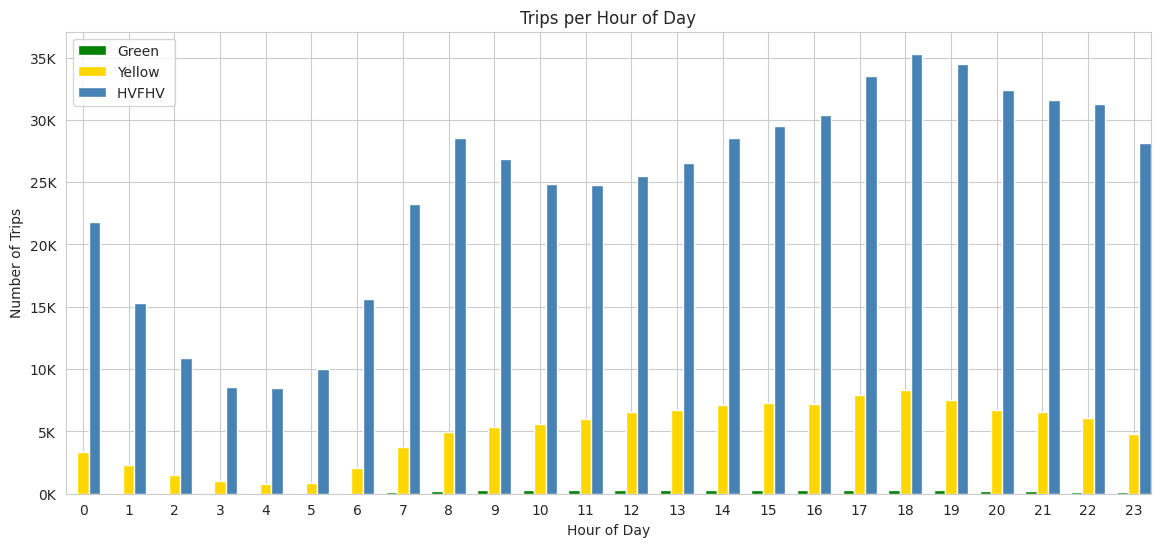

In [0]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(24)  # 0-23 hour positions
width = 0.25        # width of each bar

# Plot 
ax.bar(x - width, avg_hourly_trips_pivoted['green'],  width, label='Green', color='green')
ax.bar(x, avg_hourly_trips_pivoted['yellow'],  width, label='Yellow ', color='gold')
ax.bar(x + width, avg_hourly_trips_pivoted['hvfhv'],  width, label='HVFHV ', color='steelblue')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.set_xticks(x)
ax.set_xticklabels(range(24))
ax.margins(x=0)

# Labels
ax.set_title("Trips per Hour of Day")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Trips")
plt.legend()
plt.show()

HVFHV dominates at every hour of the day. Demand never fully drops off overnight: even at
the quietest point (4-5am) HVFHV averages around 8,500 trips per hour, reflecting the
platform's role as a 24-hour service. From 6am demand climbs steadily through the morning
commute, dips slightly across the midday hours, then builds to an evening peak at 18:00-19:00
(around 35K trips). It remains elevated through the late evening before tailing off after
midnight.

Yellow follows a similar shape at roughly a quarter of the volume, with its own evening peak
at 18:00-19:00. Green is too small to read at this scale and is effectively flat across all
hours.

#### Chart 5: Average Trips by Day of Week

In [0]:
# data is hourly, need to aggregate to daily first before avgeraging day of the week
avg_daily_trips = spark.sql("""
    SELECT
        vehicle_type,
        day_of_week,
        ROUND(AVG(daily_trips), 0) AS avg_trips
    FROM (
        SELECT
            vehicle_type,
            DATE(hour) AS date,
            DAYOFWEEK(hour) AS day_of_week,
            SUM(trip_count) AS daily_trips
        FROM hourly_demand
        WHERE hour >= '2019-01-01' AND hour < '2026-01-01'
        GROUP BY vehicle_type, date, day_of_week       
    )
    GROUP BY vehicle_type, day_of_week
""").toPandas()

avg_daily_trips_pivoted = avg_daily_trips.pivot(columns = "vehicle_type", index = "day_of_week", values = "avg_trips")
avg_daily_trips_pivoted


vehicle_type,green,hvfhv,yellow
day_of_week,,,
1,3810.0,592456.0,104212.0
2,4456.0,506369.0,107226.0
3,4748.0,527011.0,121448.0
4,4959.0,556615.0,127093.0
5,5091.0,586427.0,131222.0
6,5189.0,646679.0,128528.0
7,4545.0,687183.0,123423.0


In [0]:
# fix monday not being first day of week issue
avg_daily_trips_pivoted = avg_daily_trips_pivoted.reindex([2, 3, 4, 5, 6, 7, 1])

avg_daily_trips_pivoted

vehicle_type,green,hvfhv,yellow
day_of_week,,,
2,4456.0,506369.0,107226.0
3,4748.0,527011.0,121448.0
4,4959.0,556615.0,127093.0
5,5091.0,586427.0,131222.0
6,5189.0,646679.0,128528.0
7,4545.0,687183.0,123423.0
1,3810.0,592456.0,104212.0


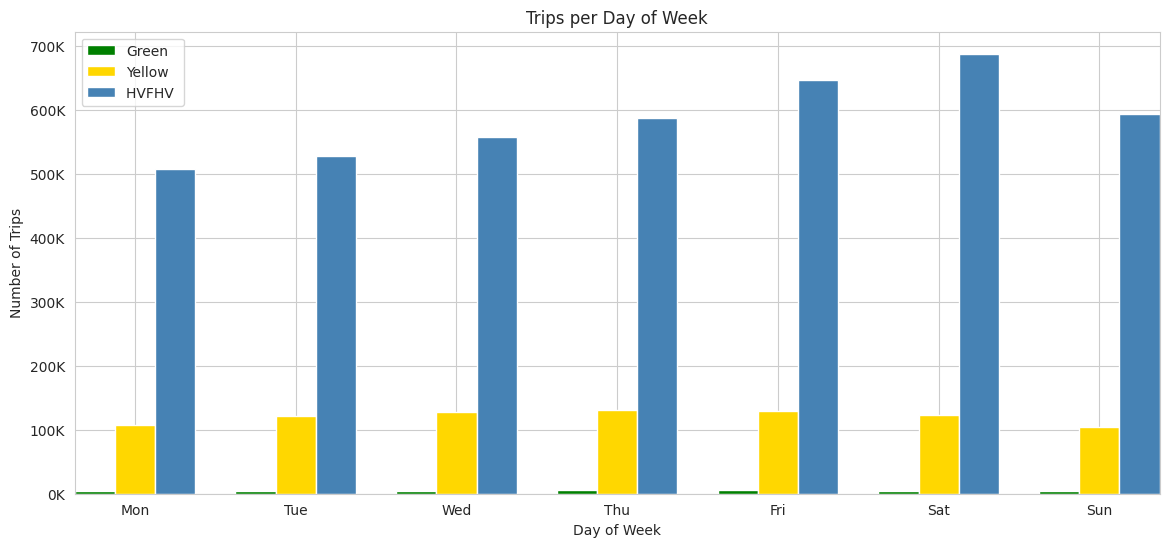

In [0]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(7)  # 1-7 day positions
width = 0.25        # width of each bar

# Plot 
ax.bar(x - width, avg_daily_trips_pivoted['green'],  width, label='Green', color='green')
ax.bar(x, avg_daily_trips_pivoted['yellow'],  width, label='Yellow ', color='gold')
ax.bar(x + width, avg_daily_trips_pivoted['hvfhv'],  width, label='HVFHV ', color='steelblue')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.set_xticks(x)
ax.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax.margins(x=0)

# Labels
ax.set_title("Trips per Day of Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Number of Trips")
plt.legend(loc='upper left')
plt.show()

HVFHV builds steadily across the working week and peaks on Saturday (around 690K daily
trips), reflecting its role in leisure and nightlife travel. Sunday remains elevated before
dropping back on Monday, the quietest day of the week. Yellow shows the opposite pattern:
strongest mid-week (Thursday/Friday) and weaker at weekends, consistent with commuter and
business demand. Green is negligible across all days.

#### Chart 6: Average Trips by Month of Year

In [0]:
# monthly totals per year first from the sub query, then average across years to get a typical month
avg_monthly_trips = spark.sql("""
    SELECT
        vehicle_type,
        month,
        ROUND(AVG(monthly_trips), 0) AS avg_trips
    FROM (
        SELECT
            vehicle_type,
            YEAR(hour) AS year,
            MONTH(hour) AS month,
            SUM(trip_count) AS monthly_trips
        FROM hourly_demand
        WHERE hour >= '2019-01-01' AND hour < '2026-01-01'
        GROUP BY vehicle_type, year, month    
        ORDER BY vehicle_type, month  
    )
    GROUP BY vehicle_type, month
""").toPandas()

avg_monthly_trips_pivoted = avg_monthly_trips.pivot(columns = "vehicle_type", index = "month", values = "avg_trips")
avg_monthly_trips_pivoted

vehicle_type,green,hvfhv,yellow
month,,,
1,204536.0,17629676.0,3920147.0
2,187574.0,18025287.0,3885397.0
3,172830.0,18881382.0,3936813.0
4,134352.0,16649084.0,3465352.0
5,136196.0,17562737.0,3695835.0
6,128483.0,17236715.0,3583120.0
7,121735.0,17245948.0,3284189.0
8,119828.0,17090050.0,3199765.0
9,124342.0,17621593.0,3540905.0


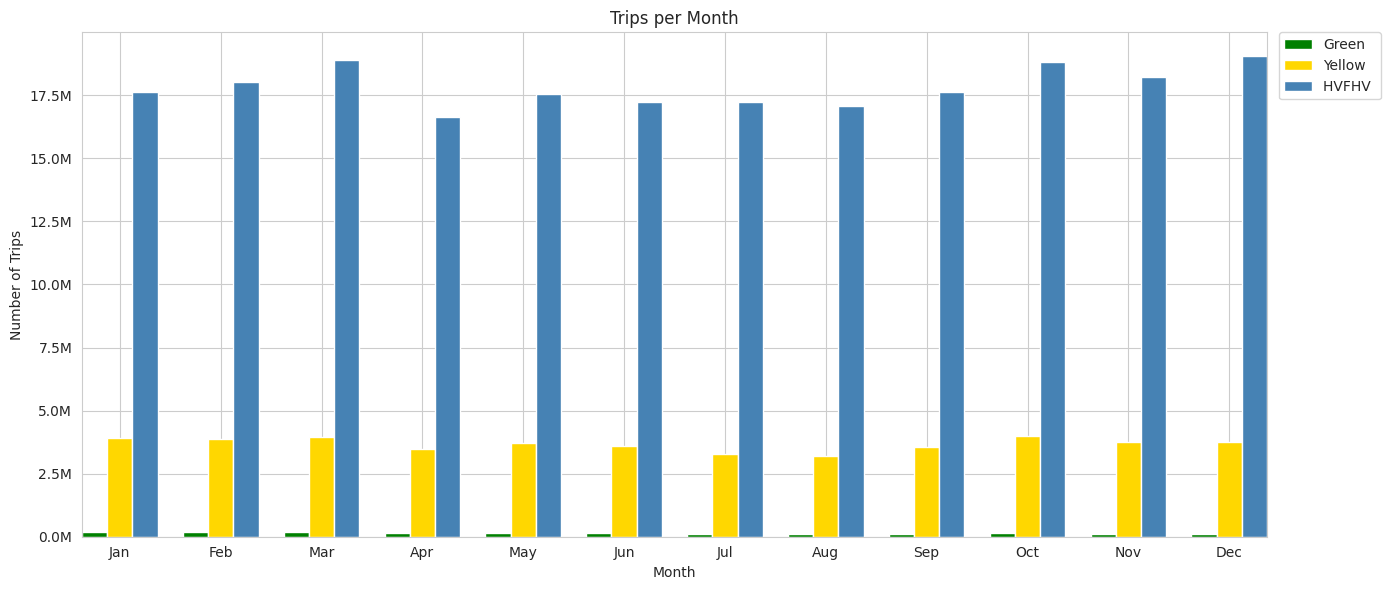

In [0]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(12)  # 1-12 month positions
width = 0.25       # width of each bar

# Plot 
ax.bar(x - width, avg_monthly_trips_pivoted['green'],  width, label='Green', color='green')
ax.bar(x, avg_monthly_trips_pivoted['yellow'],  width, label='Yellow ', color='gold')
ax.bar(x + width, avg_monthly_trips_pivoted['hvfhv'],  width, label='HVFHV ', color='steelblue')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_xticks(x)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.margins(x=0)

# Labels
ax.set_title("Trips per Month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Trips")
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

Demand is relatively stable across the calendar year for all three vehicle types. HVFHV
shows a modest dip in April and a slight uptick in the final quarter. Yellow is consistent
throughout with little seasonal variation. Green remains negligible across all months.

#### Chart 7: Average Trips by Hour of Day X Day of Week

In [0]:
avg_hourly_trips_by_dow = spark.sql("""
    SELECT
        HOUR(hour) AS hour_of_day,
        DAYOFWEEK(hour) AS day_of_week,
        ROUND(AVG(trip_count), 0) AS avg_trips
    FROM hourly_demand
    WHERE hour >= '2019-01-01' AND hour < '2026-01-01'
    GROUP BY day_of_week, hour_of_day       
""").toPandas()


avg_hourly_trips_by_dow_pivoted = avg_hourly_trips_by_dow.pivot(index='day_of_week', columns='hour_of_day', values='avg_trips')
avg_hourly_trips_by_dow_pivoted

hour_of_day,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,,,,
1,14270.0,11835.0,8840.0,6752.0,5073.0,3688.0,4135.0,4977.0,5991.0,7841.0,9794.0,10843.0,11449.0,11796.0,12196.0,12269.0,12308.0,12619.0,12795.0,11960.0,11257.0,10833.0,10206.0,8563.0
2,6003.0,3640.0,2423.0,1954.0,2455.0,3659.0,6325.0,9787.0,12151.0,10850.0,9525.0,9251.0,9520.0,9894.0,10816.0,11194.0,11278.0,12465.0,12759.0,11572.0,10653.0,10190.0,9224.0,7328.0
3,4936.0,2845.0,1840.0,1508.0,2051.0,3400.0,6394.0,10542.0,13096.0,11628.0,10015.0,9608.0,9859.0,10179.0,11184.0,11615.0,11789.0,13328.0,14013.0,12936.0,12112.0,11862.0,10996.0,8625.0
4,5684.0,3348.0,2191.0,1759.0,2215.0,3502.0,6509.0,10732.0,13347.0,11953.0,10307.0,9962.0,10259.0,10616.0,11615.0,11980.0,12269.0,13956.0,14751.0,13903.0,12880.0,12705.0,11983.0,9667.0
5,6386.0,3777.0,2437.0,1930.0,2398.0,3667.0,6668.0,10836.0,13408.0,12072.0,10536.0,10254.0,10548.0,10929.0,11982.0,12465.0,12794.0,14439.0,15330.0,14674.0,13715.0,13542.0,13178.0,11366.0
6,8261.0,5265.0,3483.0,2604.0,2854.0,3868.0,6618.0,10472.0,12856.0,11684.0,10633.0,10560.0,10992.0,11494.0,12568.0,12987.0,13395.0,15054.0,16368.0,16576.0,15089.0,14573.0,15363.0,15127.0
7,13035.0,10270.0,7862.0,5826.0,4453.0,3549.0,4458.0,5709.0,7390.0,9238.0,10534.0,11545.0,12285.0,12774.0,13136.0,13606.0,14019.0,15043.0,16035.0,16466.0,15536.0,15301.0,16084.0,16076.0


In [0]:
avg_hourly_trips_by_dow_pivoted = avg_hourly_trips_by_dow_pivoted.reindex([2, 3, 4, 5, 6, 7, 1])
avg_hourly_trips_by_dow_pivoted

hour_of_day,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,,,,
2,6003.0,3640.0,2423.0,1954.0,2455.0,3659.0,6325.0,9787.0,12151.0,10850.0,9525.0,9251.0,9520.0,9894.0,10816.0,11194.0,11278.0,12465.0,12759.0,11572.0,10653.0,10190.0,9224.0,7328.0
3,4936.0,2845.0,1840.0,1508.0,2051.0,3400.0,6394.0,10542.0,13096.0,11628.0,10015.0,9608.0,9859.0,10179.0,11184.0,11615.0,11789.0,13328.0,14013.0,12936.0,12112.0,11862.0,10996.0,8625.0
4,5684.0,3348.0,2191.0,1759.0,2215.0,3502.0,6509.0,10732.0,13347.0,11953.0,10307.0,9962.0,10259.0,10616.0,11615.0,11980.0,12269.0,13956.0,14751.0,13903.0,12880.0,12705.0,11983.0,9667.0
5,6386.0,3777.0,2437.0,1930.0,2398.0,3667.0,6668.0,10836.0,13408.0,12072.0,10536.0,10254.0,10548.0,10929.0,11982.0,12465.0,12794.0,14439.0,15330.0,14674.0,13715.0,13542.0,13178.0,11366.0
6,8261.0,5265.0,3483.0,2604.0,2854.0,3868.0,6618.0,10472.0,12856.0,11684.0,10633.0,10560.0,10992.0,11494.0,12568.0,12987.0,13395.0,15054.0,16368.0,16576.0,15089.0,14573.0,15363.0,15127.0
7,13035.0,10270.0,7862.0,5826.0,4453.0,3549.0,4458.0,5709.0,7390.0,9238.0,10534.0,11545.0,12285.0,12774.0,13136.0,13606.0,14019.0,15043.0,16035.0,16466.0,15536.0,15301.0,16084.0,16076.0
1,14270.0,11835.0,8840.0,6752.0,5073.0,3688.0,4135.0,4977.0,5991.0,7841.0,9794.0,10843.0,11449.0,11796.0,12196.0,12269.0,12308.0,12619.0,12795.0,11960.0,11257.0,10833.0,10206.0,8563.0


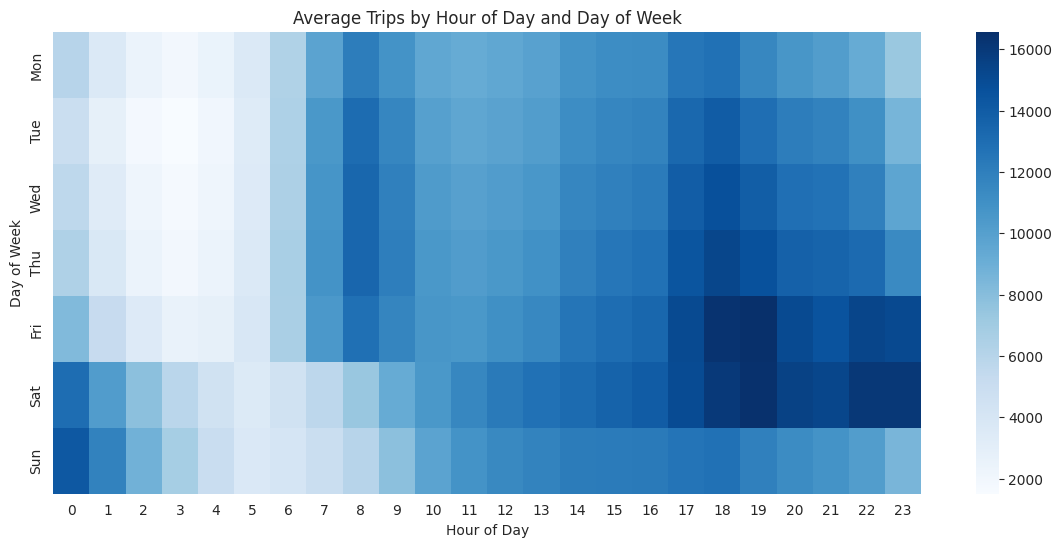

In [0]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    avg_hourly_trips_by_dow_pivoted,
    ax=ax,
    cmap='Blues',
    fmt='.0f'
)

ax.set_title("Average Trips by Hour of Day and Day of Week")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")
ax.set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.show()

The heatmap combines the hourly and day-of-week patterns into a single view. 

The 4-5am trough is the quietest window across every day of the week. Friday and Saturday evenings
(18:00-23:00) are the peak demand cells in the entire grid. The late-night weekend hours
(0-3am on Saturday and Sunday) are notably darker than their weekday equivalents, reflecting
leisure and nightlife demand. Weekday mornings show a steady ramp from around 7am but never
reach the intensity of the weekend evening peak.
